# Artificial Intelligence Coursework

## Development in Colab Environment

### Importing modules and libraries

In [1]:
import random
import torch
import torch.nn.parallel
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import glob

### For colab

In [ ]:
!unzip /content/drive/MyDrive/data.zip -d ./data

### Preparing Configuration

In [ ]:
# Set random seed for reproducibility
manualSeed = random.randint(1, 10000)
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)


Random Seed:  5981


In [ ]:
#only for DCGAN
torch.use_deterministic_algorithms(True) # Needed for reproducible results

In [ ]:
#Config for DCGAN
# Root directory for dataset
dataroot = "data"

# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 32

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 64

ngpu = 1

num_epochs = 5

device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

In [ ]:
#Config for DDPM
@dataclass
class TrainingConfig:

    image_size = image_size  # the generated image resolution

    train_batch_size = batch_size

    eval_batch_size = batch_size  # how many images to sample during evaluation

    num_epochs = num_epochs

    gradient_accumulation_steps = 1

    learning_rate = 1e-4

    lr_warmup_steps = 500

    save_image_epochs = 5

    save_model_epochs = 5

    mixed_precision = "fp16"  # `no` for float32, `fp16` for automatic mixed precision

    output_dir = "ddpm-anime"  # the model name locally and on the HF Hub

    overwrite_output_dir = True  # overwrite the old model when re-running the notebook

    seed = manualSeed

In [ ]:
device

device(type='cuda', index=0)

### Loading and pre-processing dataset

In [ ]:
# Create the dataset
dataset = dset.ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                           ]))

dataset

Dataset ImageFolder
    Number of datapoints: 100310
    Root location: data
    StandardTransform
Transform: Compose(
               Resize(size=64, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(64, 64))
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [ ]:
# Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

dataloader

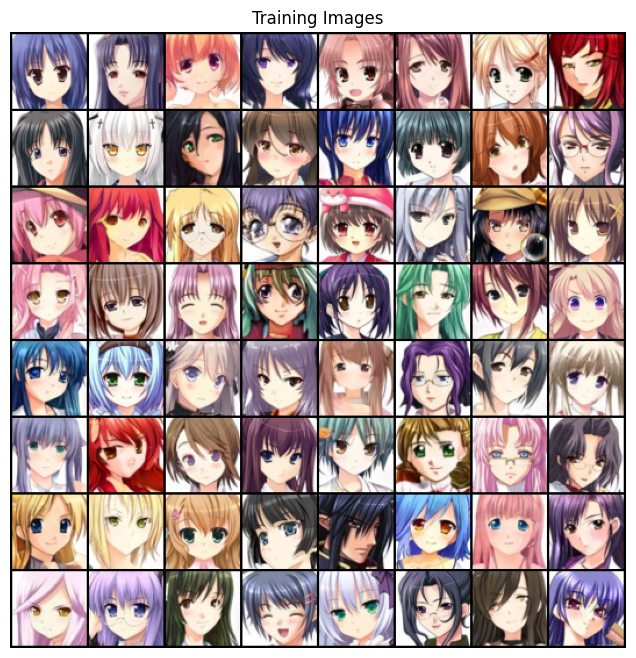

In [ ]:
# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

### DCGAN

In [ ]:
from dcgan import DCGAN

In [ ]:
model = DCGAN()
model

In [ ]:
model.fit(num_epochs, dataloader)

Starting Training Loop...
[0/5][391/392]	Loss_D: 0.6510	Loss_G: 7.4602	D(x): 0.9529	D(G(z)): 0.3958 / 0.0010
[1/5][391/392]	Loss_D: 0.3627	Loss_G: 4.2890	D(x): 0.8300	D(G(z)): 0.1183 / 0.0191
[2/5][391/392]	Loss_D: 0.8439	Loss_G: 9.9069	D(x): 0.9881	D(G(z)): 0.4790 / 0.0001
[3/5][391/392]	Loss_D: 0.5209	Loss_G: 4.2076	D(x): 0.6807	D(G(z)): 0.0109 / 0.0270
[4/5][391/392]	Loss_D: 0.2978	Loss_G: 5.5340	D(x): 0.8967	D(G(z)): 0.1423 / 0.0077


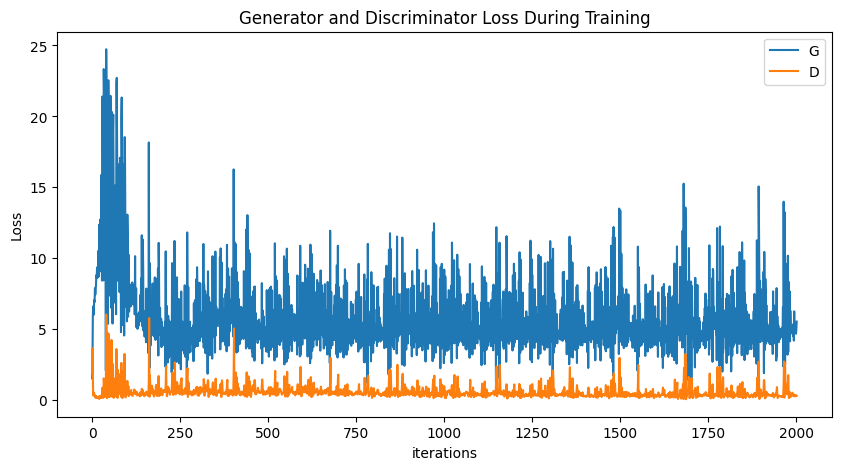

In [ ]:
model.plot_loss(plt)

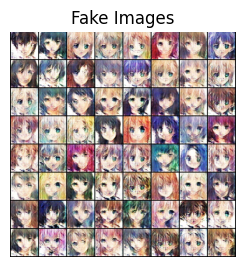

In [ ]:
model.plot_fake(plt)

### DDPM

In [ ]:
from ddpm import DDPM

In [ ]:
config = TrainingConfig()
model = DDPM(config)

In [ ]:
model.fit(dataloader)

Launching training on one GPU.


  0%|          | 0/392 [00:00<?, ?it/s]

TypeError: list indices must be integers or slices, not str

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
from datasets import load_dataset

config.dataset_name = "data"

dataset = load_dataset('imagefolder', data_dir=config.dataset_name, split='train')

dataset

Resolving data files:   0%|          | 0/100315 [00:00<?, ?it/s]

Dataset({
    features: ['image'],
    num_rows: 100309
})

In [ ]:
preprocess = transforms.Compose(
    [
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}


dataset.set_transform(transform)

In [ ]:
train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=config.train_batch_size, shuffle=True)

In [ ]:
model.fit(train_dataloader)

Launching training on one GPU.


  0%|          | 0/392 [00:00<?, ?it/s]

RuntimeError: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility

In [ ]:
torch.use_deterministic_algorithms(False)

In [ ]:
model.fit(train_dataloader)

Launching training on one GPU.


  0%|          | 0/3135 [00:00<?, ?it/s]

  0%|          | 0/3135 [00:00<?, ?it/s]

  0%|          | 0/3135 [00:00<?, ?it/s]

  0%|          | 0/3135 [00:00<?, ?it/s]

  0%|          | 0/3135 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

AssertionError: 

In [ ]:
from PIL import Image
import glob

sample_images = sorted(glob.glob(f"{config.output_dir}/samples/*.png"))
Image.open(sample_images[-1])

## Development in Local Environment

### Initialization

In [1]:
import random
import torch
import torch.nn.parallel
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import glob

In [2]:
# Set random seed for reproducibility
manualSeed = random.randint(1, 10000)
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

Random Seed:  1343


In [3]:
#Config for DCGAN

torch.use_deterministic_algorithms(True) # Needed for reproducible results

# Root directory for dataset
dataroot = "data"

# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 16

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 64

ngpu = 1

num_epochs = 10

device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

In [7]:
#Config for DDPM
@dataclass
class TrainingConfig:

    image_size = image_size  # the generated image resolution

    train_batch_size = batch_size

    eval_batch_size = batch_size  # how many images to sample during evaluation

    num_epochs = num_epochs

    gradient_accumulation_steps = 1

    learning_rate = 1e-4

    lr_warmup_steps = 500

    save_image_epochs = 5

    save_model_epochs = 5

    mixed_precision = "fp16"  # `no` for float32, `fp16` for automatic mixed precision

    output_dir = "ddpm-anime"  # the model name locally and on the HF Hub

    overwrite_output_dir = True  # overwrite the old model when re-running the notebook

    seed = manualSeed

### DCGAN - 100 Epoch Minimal Dataset

In [17]:
from torch.utils.data import random_split

# Create the dataset
dataset = dset.ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                           ]))

# Length of the dataset
total_len = len(dataset)

# Length of subset(20% of dataset)
subset_len = int(0.01 * total_len)

subset, _ = random_split(dataset, [subset_len, total_len - subset_len])

len(subset)

1003

In [6]:
# Create the dataloader
dataloader = torch.utils.data.DataLoader(subset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

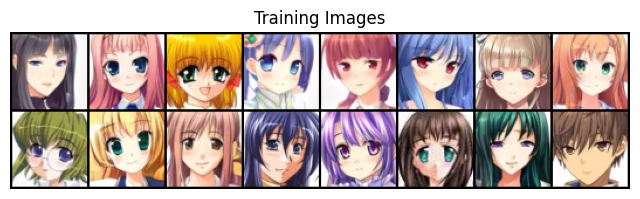

In [7]:
# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [7]:
from models.dcgan import DCGAN

In [8]:
model = DCGAN()

In [12]:
model.fit(100, dataloader)

Starting Training Loop...
Epoch: 0 	Loss_D: 0.4495	Loss_G: 3.2568	D(x): 0.7371	D(G(z)): 0.0204 / 0.1207
Epoch: 1 	Loss_D: 0.0666	Loss_G: 9.0632	D(x): 0.9538	D(G(z)): 0.0165 / 0.0004
Epoch: 2 	Loss_D: 0.2084	Loss_G: 5.9409	D(x): 0.9614	D(G(z)): 0.1514 / 0.0031
Epoch: 3 	Loss_D: 0.5171	Loss_G: 7.0045	D(x): 0.6577	D(G(z)): 0.0053 / 0.0048
Epoch: 4 	Loss_D: 0.4465	Loss_G: 7.5046	D(x): 0.9805	D(G(z)): 0.3141 / 0.0009
Epoch: 5 	Loss_D: 0.5735	Loss_G: 9.2673	D(x): 0.9552	D(G(z)): 0.2884 / 0.0002
Epoch: 6 	Loss_D: 0.3571	Loss_G: 7.4275	D(x): 0.9660	D(G(z)): 0.2556 / 0.0008
Epoch: 7 	Loss_D: 0.6305	Loss_G: 8.2822	D(x): 0.9044	D(G(z)): 0.3369 / 0.0007
Epoch: 8 	Loss_D: 3.3245	Loss_G: 5.5294	D(x): 0.1914	D(G(z)): 0.0000 / 0.0070
Epoch: 9 	Loss_D: 0.5021	Loss_G: 5.3828	D(x): 0.7181	D(G(z)): 0.0058 / 0.0223
Epoch: 10 	Loss_D: 0.3487	Loss_G: 5.7485	D(x): 0.9187	D(G(z)): 0.1478 / 0.0051
Epoch: 11 	Loss_D: 0.0891	Loss_G: 6.1667	D(x): 0.9395	D(G(z)): 0.0158 / 0.0080
Epoch: 12 	Loss_D: 0.2288	Loss_G: 5.

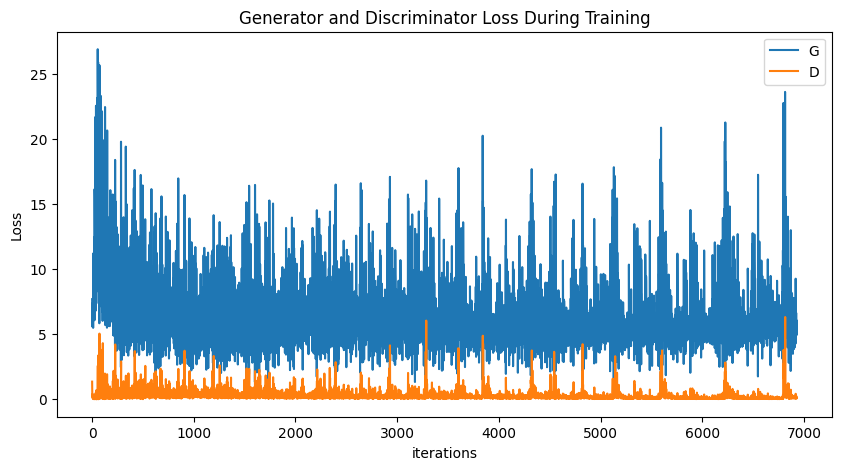

In [13]:
model.plot_loss(plt)

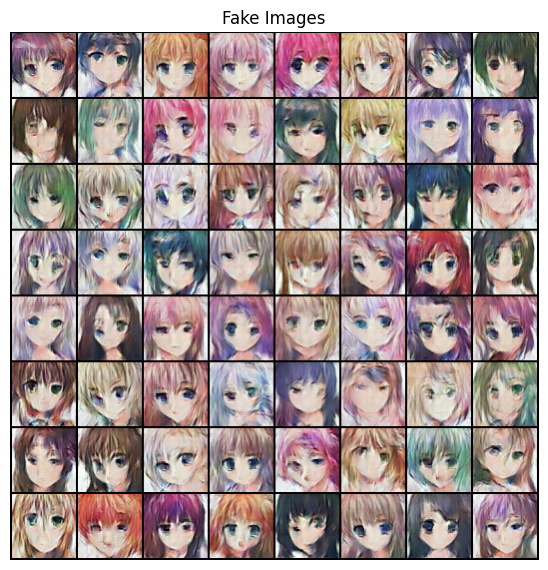

In [15]:
model.plot_fake(plt)

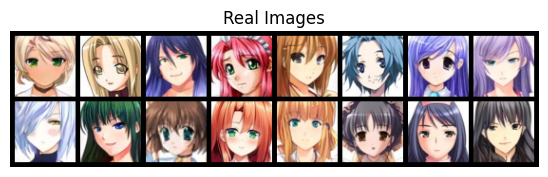

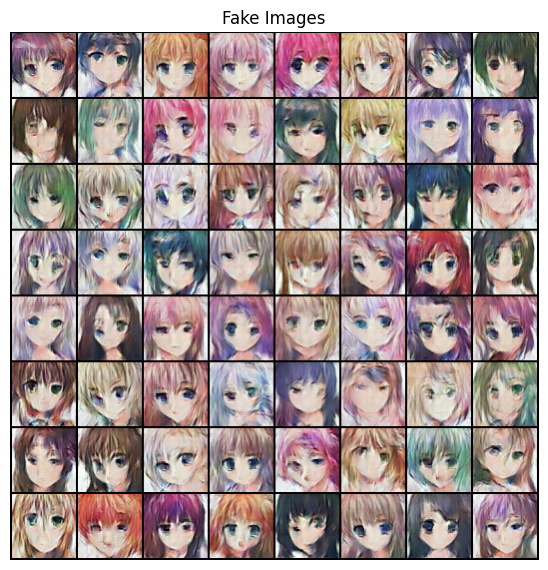

In [16]:
model.plot_compare(dataloader, plt)

### DDPM - 25 Epoch Minimal Dataset

In [8]:
from datasets import load_dataset

config = TrainingConfig()

config.dataset_name = "data"

dataset = load_dataset('imagefolder', data_dir=config.dataset_name, split='train')

dataset


Dataset({
    features: ['image'],
    num_rows: 100309
})

In [9]:
preprocess = transforms.Compose(
    [
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}


dataset.set_transform(transform)

In [7]:
from torch.utils.data import random_split

# Length of the dataset
total_len = len(dataset)

# Length of subset(10% of dataset)
subset_len = int(0.01 * total_len)

subset, _ = random_split(dataset, [subset_len, total_len - subset_len])

len(subset)

1003

In [8]:
train_dataloader = torch.utils.data.DataLoader(subset, batch_size=config.train_batch_size, shuffle=True)

In [13]:
from models.ddpm import DDPM

model = DDPM(config)
model.config.num_epochs = 25

In [11]:
torch.use_deterministic_algorithms(False) # Needed for remove for DDPM

In [15]:
model.fit(train_dataloader)

Launching training on one GPU.


Epoch 24: 100%|██████████| 63/63 [01:44<00:00,  1.66s/it, loss=0.0379, lr=0, step=1574]


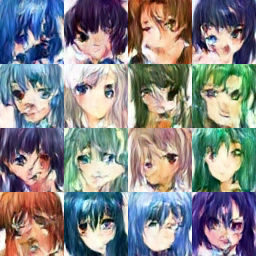

In [16]:
from PIL import Image

sample_images = sorted(glob.glob(f"{config.output_dir}/samples/*.png"))
Image.open(sample_images[-1])

### Full Dataset 10 Epoch DCGAN 16 Batch Size

In [4]:
dataset = dset.ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                           ]))

print(len(dataset))

dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

100310


In [23]:
from models.dcgan import DCGAN
model = DCGAN()
model.fit(10, dataloader)

Starting Training Loop...
Epoch: 0 	Loss_D: 1.3771	Loss_G: 5.4750	D(x): 0.4450	D(G(z)): 0.0009 / 0.0122
Epoch: 1 	Loss_D: 0.7691	Loss_G: 14.1342	D(x): 0.9989	D(G(z)): 0.4311 / 0.0000
Epoch: 2 	Loss_D: 1.1522	Loss_G: 0.5740	D(x): 0.4319	D(G(z)): 0.0029 / 0.6874
Epoch: 3 	Loss_D: 0.0456	Loss_G: 4.8532	D(x): 0.9753	D(G(z)): 0.0199 / 0.0089
Epoch: 4 	Loss_D: 0.1256	Loss_G: 5.8520	D(x): 0.9791	D(G(z)): 0.0932 / 0.0042
Epoch: 5 	Loss_D: 0.0325	Loss_G: 6.2573	D(x): 0.9917	D(G(z)): 0.0236 / 0.0024
Epoch: 6 	Loss_D: 0.0136	Loss_G: 6.1329	D(x): 0.9900	D(G(z)): 0.0035 / 0.0041
Epoch: 7 	Loss_D: 0.0029	Loss_G: 7.1361	D(x): 0.9996	D(G(z)): 0.0025 / 0.0023
Epoch: 8 	Loss_D: 0.0460	Loss_G: 7.1917	D(x): 0.9999	D(G(z)): 0.0443 / 0.0012
Epoch: 9 	Loss_D: 0.0057	Loss_G: 6.4488	D(x): 0.9997	D(G(z)): 0.0054 / 0.0028


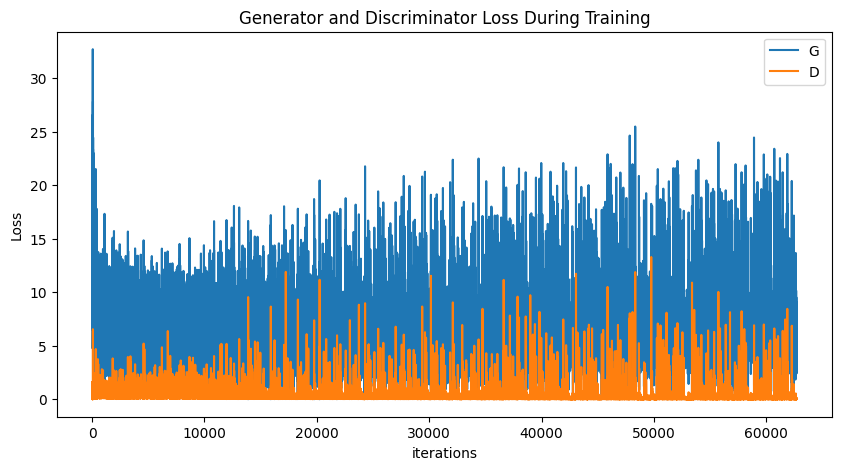

In [24]:
model.plot_loss(plt)

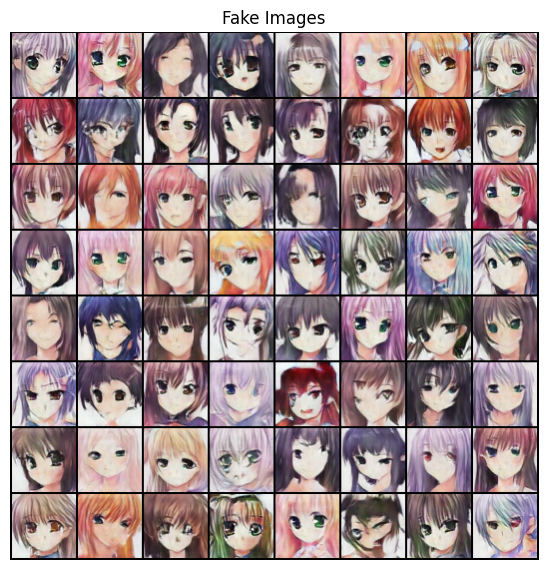

In [25]:
model.plot_fake(plt)

### Full Dataset 10 Epoch DCGAN 64 Batch Size

In [26]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64,
                                         shuffle=True, num_workers=workers)

model = DCGAN()
model.fit(10, dataloader)

Starting Training Loop...
Epoch: 0 	Loss_D: 1.0294	Loss_G: 8.8738	D(x): 0.9938	D(G(z)): 0.5859 / 0.0005
Epoch: 1 	Loss_D: 0.7946	Loss_G: 8.1334	D(x): 0.9164	D(G(z)): 0.3434 / 0.0008
Epoch: 2 	Loss_D: 0.4121	Loss_G: 8.0177	D(x): 0.9644	D(G(z)): 0.2713 / 0.0004
Epoch: 3 	Loss_D: 0.2512	Loss_G: 4.7500	D(x): 0.9401	D(G(z)): 0.1432 / 0.0112
Epoch: 4 	Loss_D: 1.4443	Loss_G: 4.9118	D(x): 0.9422	D(G(z)): 0.6344 / 0.0206
Epoch: 5 	Loss_D: 1.1909	Loss_G: 1.2827	D(x): 0.3797	D(G(z)): 0.0148 / 0.3825
Epoch: 6 	Loss_D: 1.1292	Loss_G: 1.8885	D(x): 0.4458	D(G(z)): 0.0172 / 0.2125
Epoch: 7 	Loss_D: 0.1932	Loss_G: 5.6843	D(x): 0.9816	D(G(z)): 0.1471 / 0.0054
Epoch: 8 	Loss_D: 0.3767	Loss_G: 2.0323	D(x): 0.7532	D(G(z)): 0.0159 / 0.2208
Epoch: 9 	Loss_D: 0.0978	Loss_G: 3.3369	D(x): 0.9253	D(G(z)): 0.0165 / 0.0551


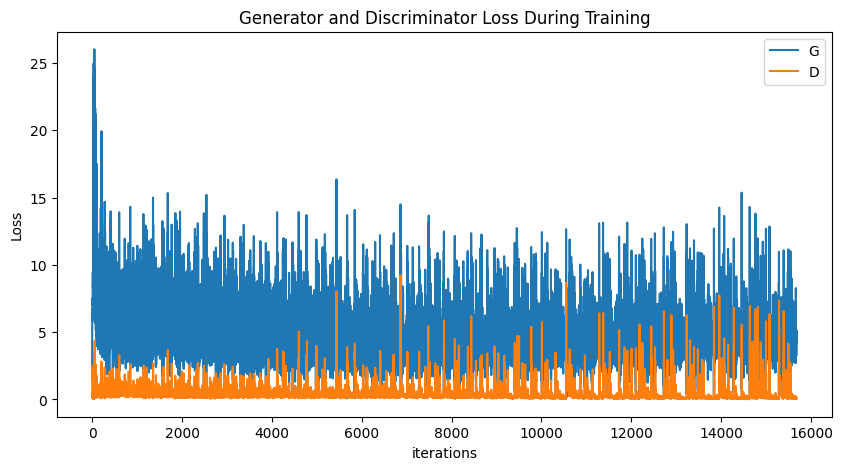

In [27]:
model.plot_loss(plt)

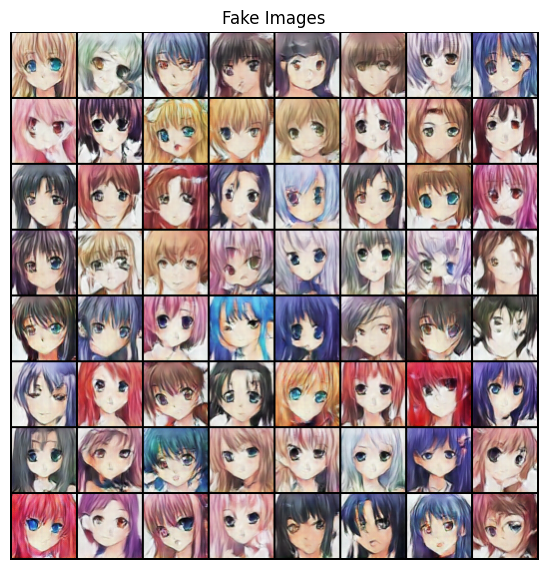

In [28]:
model.plot_fake(plt)

### Full Dataset 10 Epoch DCGAN 128 Batch Size

In [29]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128,
                                         shuffle=True, num_workers=workers)

model = DCGAN()
model.fit(10, dataloader)

Starting Training Loop...
Epoch: 0 	Loss_D: 1.0223	Loss_G: 5.7480	D(x): 0.5051	D(G(z)): 0.0012 / 0.0062
Epoch: 1 	Loss_D: 0.4494	Loss_G: 3.5144	D(x): 0.7149	D(G(z)): 0.0226 / 0.0415
Epoch: 2 	Loss_D: 0.2614	Loss_G: 4.2518	D(x): 0.9521	D(G(z)): 0.1724 / 0.0234
Epoch: 3 	Loss_D: 0.1817	Loss_G: 3.1439	D(x): 0.8956	D(G(z)): 0.0471 / 0.0794
Epoch: 4 	Loss_D: 0.5944	Loss_G: 1.6784	D(x): 0.6170	D(G(z)): 0.0173 / 0.2448
Epoch: 5 	Loss_D: 0.2649	Loss_G: 4.4116	D(x): 0.9308	D(G(z)): 0.1606 / 0.0200
Epoch: 6 	Loss_D: 0.9012	Loss_G: 3.3850	D(x): 0.4947	D(G(z)): 0.0046 / 0.0574
Epoch: 7 	Loss_D: 0.9543	Loss_G: 2.1156	D(x): 0.4674	D(G(z)): 0.0308 / 0.1730
Epoch: 8 	Loss_D: 0.2449	Loss_G: 4.0689	D(x): 0.9250	D(G(z)): 0.1437 / 0.0232
Epoch: 9 	Loss_D: 0.6457	Loss_G: 3.9289	D(x): 0.6144	D(G(z)): 0.0136 / 0.0391


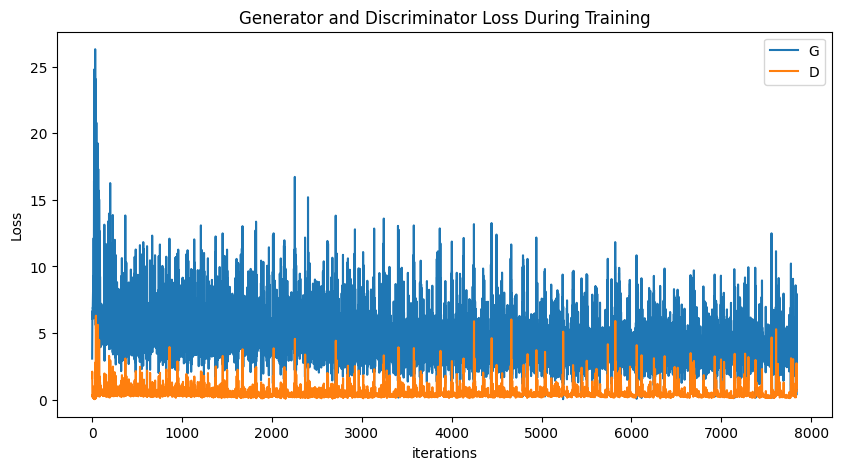

In [30]:
model.plot_loss(plt)

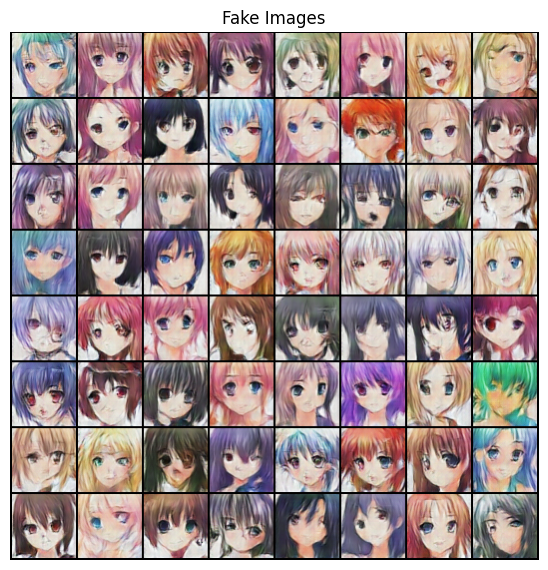

In [31]:
model.plot_fake(plt)